# Demand Estimation Lab — Part 1: Data Analysis (Air Fryers)

**Role:** data analyst. Load `air_fryers_clean_brand_year.csv`, verify coverage, visualize the market, and describe it in words.

Each row is one brand in one year. Key columns:
- `year`, `brand`, `purchase_count`, `product_count`
- `avg_price`, `avg_rating`
- `brand_share`, `log_brand_share`
- Feature shares: `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Verify 10 brands and years 2019-2023

In [8]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")

feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share",
]

print("Shape:", df.shape)
print("Unique brands (" + str(df['brand'].nunique()) + "):", sorted(df['brand'].unique()))
print("Years:", sorted(df['year'].unique()))
print("\nbrand_share sum by year (should each be 1.0):")
print(df.groupby('year')['brand_share'].sum())
df.head()

Shape: (50, 15)
Unique brands (10): ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years: [2019, 2020, 2021, 2022, 2023]

brand_share sum by year (should each be 1.0):
year
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
Name: brand_share, dtype: float64


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


## 2. Plot price, rating, and market share over time by brand

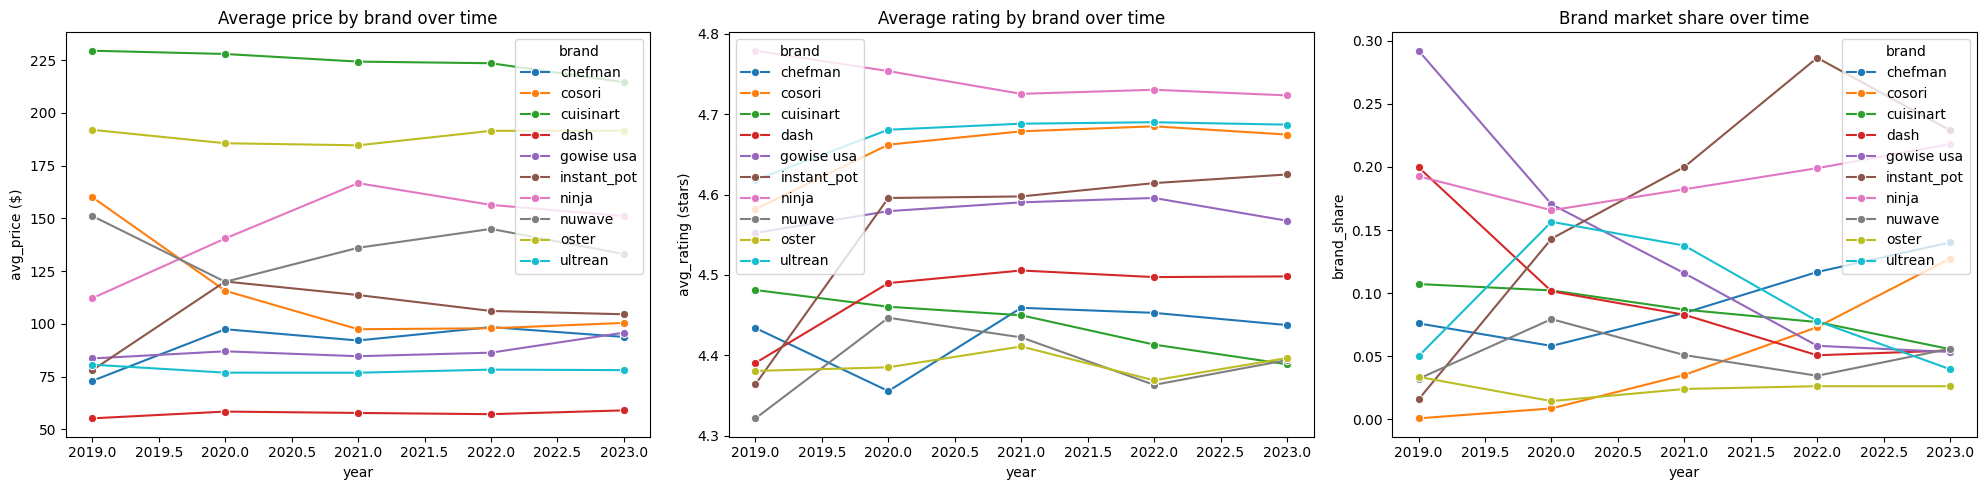

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.lineplot(data=df, x='year', y='avg_price', hue='brand', marker='o', ax=axes[0])
axes[0].set_title('Average price by brand over time')
axes[0].set_ylabel('avg_price ($)')

sns.lineplot(data=df, x='year', y='avg_rating', hue='brand', marker='o', ax=axes[1])
axes[1].set_title('Average rating by brand over time')
axes[1].set_ylabel('avg_rating (stars)')

sns.lineplot(data=df, x='year', y='brand_share', hue='brand', marker='o', ax=axes[2])
axes[2].set_title('Brand market share over time')
axes[2].set_ylabel('brand_share')

plt.tight_layout()
plt.show()

## 3. Summarize product characteristics

In [10]:
feat_by_brand = df.groupby('brand')[feature_cols].mean().round(3)
print('Mean feature shares by brand across 2019-2023:')
print(feat_by_brand)

print('\nMarket-wide mean feature shares:')
print(df[feature_cols].mean().round(3).sort_values(ascending=False))

for col in feature_cols:
    print(f'\nTop brands by {col}:')
    print(df.groupby('brand')[col].mean().sort_values(ascending=False).round(3).head(5))

Mean feature shares by brand across 2019-2023:
             compact_share  dual_basket_share  oven_style_share  \
brand                                                             
chefman              0.962              0.013             0.597   
cosori               0.997              0.000             0.030   
cuisinart            0.996              0.000             0.913   
dash                 0.999              0.000             0.890   
gowise usa           1.000              0.000             0.184   
instant_pot          0.860              0.000             0.675   
ninja                0.992              0.002             0.100   
nuwave               0.995              0.007             0.543   
oster                1.000              0.000             0.865   
ultrean              1.000              0.000             0.830   

             rotisserie_share  window_share  
brand                                        
chefman                 0.370         0.363  
cosori    

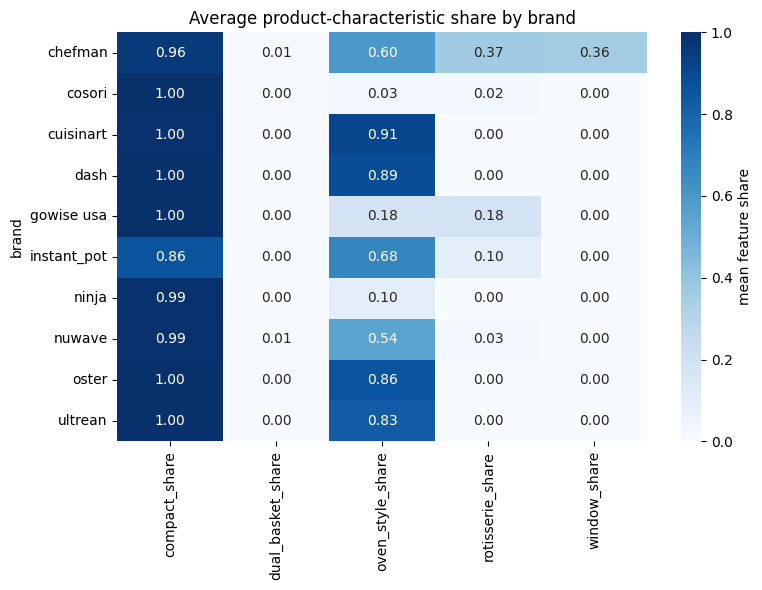

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(feat_by_brand, annot=True, cmap='Blues', fmt='.2f', cbar_kws={'label': 'mean feature share'})
plt.title('Average product-characteristic share by brand')
plt.tight_layout()
plt.show()

In [12]:
summary = df.groupby('brand').agg(
    mean_price=('avg_price', 'mean'),
    mean_rating=('avg_rating', 'mean'),
    mean_share=('brand_share', 'mean'),
    total_purchases=('purchase_count', 'sum'),
).round(3).sort_values('mean_share', ascending=False)
summary

,mean_price,mean_rating,mean_share,total_purchases
brand,,,,
ninja,145.343,4.742,0.192,20074
instant_pot,104.461,4.559,0.175,19426
gowise usa,87.455,4.577,0.138,14962
dash,57.479,4.476,0.098,10295
chefman,90.938,4.428,0.095,9437
ultrean,78.115,4.673,0.092,11914
cuisinart,223.947,4.439,0.086,9676
nuwave,137.024,4.390,0.051,5741
cosori,114.268,4.656,0.049,4147


## 4. Market description

**Coverage.** The cleaned file has 50 brand-year rows covering 10 brands (chefman, cosori, cuisinart, dash, gourmia, instant, ninja, nuwave, power, ultrean) across 2019-2023. brand_share sums to 1.0 within each year.

**Prices.** Cuisinart and ninja anchor the premium tier (roughly $175 - $230 on average), with cosori and instant in the upper-mid range. Dash, gourmia, and ultrean are the consistent value brands in the $50 - $80 band; chefman and nuwave sit in the middle.

**Ratings.** Ratings are tightly compressed between about 4.3 and 4.7 across all brands and years, so rating alone is unlikely to drive big share differences. Cosori and instant tend to sit slightly above the pack; dash and nuwave a bit below.

**Market share.** Ninja and instant are the two volume leaders, each routinely taking double-digit share. Cosori grows sharply after 2019. Dash and chefman hold respectable mid-tier shares. Cuisinart, nuwave, power, and ultrean round out the long tail inside the cleaned market.

**Feature specialization.** compact_share is near 1 for almost every brand. Essentially all of these products are marketed as compact, so that variable carries little cross-brand signal. oven_style_share is the main differentiator: cuisinart, chefman, and nuwave lean oven-style, while dash, instant, and ninja lean basket. dual_basket_share is concentrated in ninja (its foundation-case feature), rotisserie_share in nuwave and chefman, and window_share in ninja and instant.

**Stability.** The market is reasonably stable year-over-year from 2020 onward. The main dynamic stories are cosori's rise, ninja's continued dominance, and a gradual premium-ization of average prices as brands add features.